In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load Stock_TCJM ───────────────────────────────────────────────────────────
f         = np.load('Stock_TCJM.npz', allow_pickle=True)
Stock_TCJM = f['data']           # (501, 501, 4, 7): [time, cohort, type, material]
types      = list(f['types'])    # dwelling type names (axis 2)
materials  = list(f['materials'])# material names (axis 3)
years      = f['years']          # 1600–2100

print("Stock_TCJM shape:", Stock_TCJM.shape)
print("Types:", types)
print("Materials:", materials)

Stock_TCJM shape: (501, 501, 4, 7)
Types: [np.str_('Parcelhus'), np.str_('Rekkehus'), np.str_('Etagehus'), np.str_('Stuehus')]
Materials: [np.str_('concrete'), np.str_('brick'), np.str_('wood'), np.str_('steel'), np.str_('glass'), np.str_('aluminum'), np.str_('copper')]


In [18]:
# ── Carbon intensity (GWP) per material [kgCO2e / kg] ────────────────────────
# From EPD data collected in ghg epds.xlsx
ghg_df = pd.read_excel("ghg epds.xlsx", skiprows=5)
CI = ghg_df[["Material", "GWP avg"]].head(7)
print(CI.to_string(index=False))

# GWP vector — order must match materials axis in Stock_TCJM
# Stock_TCJM materials order: concrete, brick, wood, steel, glass, aluminum, copper
# GWP file order:             Concrete, Brick, Wood, Steel, Glass, Aluminium, Copper  ✓
gwp = CI["GWP avg"].values  # (7,) [kgCO2e/kg]

 Material   GWP avg
 Concrete  0.206481
    Brick  0.189735
     Wood  0.055150
    Steel  1.105450
   Glass   2.650200
Aluminium 10.000500
   Copper  7.318000


In [19]:
# ── Emissions: embodied carbon at time of construction ────────────────────────
# Emissions happen when materials are manufactured, i.e. when the building is built.
# For cohort c, this occurs at time t = c (the construction year).
# So: Inflow_CJM[c, j, m] = Stock_TCJM[c, c, j, m]  ← diagonal of the time-cohort axes
#
# This extracts all 501 diagonal entries at once (no loop needed):
n_c = Stock_TCJM.shape[1]
Inflow_CJM = Stock_TCJM[np.arange(n_c), np.arange(n_c), :, :]  # (501, 4, 7): [cohort, type, material]

# Emissions_CJM[c, j, m] = Inflow_CJM[c, j, m] * GWP[m]
# = kgCO2e emitted when cohort c, type j, material m is built
Emissions_CJM = np.einsum('cjm,m->cjm', Inflow_CJM, gwp)  # (501, 4, 7)

print("Emissions_CJM shape:", Emissions_CJM.shape)
print("Dimensions: [cohort, type, material]")

Emissions_CJM shape: (501, 4, 7)
Dimensions: [cohort, type, material]


In [20]:
# ══ SCENARIO 1 CI — comment this cell in/out to toggle ══════════════════════
# New GWP values from ghg_scen1.xlsx, measure starts 2025, fully adopted 2040.
# Cohorts built before 2025: baseline GWP unchanged.
# Cohorts 2025–2040: linear blend from baseline to scenario 1 GWP.
# Cohorts after 2040: scenario 1 GWP fully applied.

'''
ghg_s1 = pd.read_excel("ghg_scen1.xlsx", skiprows=5)        # ← adjust once file is readable
CI_scen1 = ghg_s1[["Material", "GWP avg"]].head(7)                # (7,) same material order
print(CI_scen1.to_string(index=False))
gwp_scen1 = CI_scen1["GWP avg"].values 

# Ramp: 0 at 2025, 1 at 2040 — applied per cohort year
scen1_ci_ramp = np.clip((years - 2025) / (2040 - 2025), 0, 1)  # (501,)

# Blend GWP per cohort: gwp_c[c, m] = (1-r)*gwp[m] + r*gwp_scen1[m]
gwp_C = ((1 - scen1_ci_ramp[:, np.newaxis]) * gwp[np.newaxis, :]
         + scen1_ci_ramp[:, np.newaxis] * gwp_scen1[np.newaxis, :])  # (501, 7)

# Recalculate emissions with scenario CI
# Inflow_CJM[c,j,m] × gwp_C[c,m] → Emissions_CJM[c,j,m]
Emissions_CJM = np.einsum('cjm,cm->cjm', Inflow_CJM, gwp_C)'''


'\nghg_s1 = pd.read_excel("ghg_scen1.xlsx", skiprows=5)        # ← adjust once file is readable\nCI_scen1 = ghg_s1[["Material", "GWP avg"]].head(7)                # (7,) same material order\nprint(CI_scen1.to_string(index=False))\ngwp_scen1 = CI_scen1["GWP avg"].values \n\n# Ramp: 0 at 2025, 1 at 2040 — applied per cohort year\nscen1_ci_ramp = np.clip((years - 2025) / (2040 - 2025), 0, 1)  # (501,)\n\n# Blend GWP per cohort: gwp_c[c, m] = (1-r)*gwp[m] + r*gwp_scen1[m]\ngwp_C = ((1 - scen1_ci_ramp[:, np.newaxis]) * gwp[np.newaxis, :]\n         + scen1_ci_ramp[:, np.newaxis] * gwp_scen1[np.newaxis, :])  # (501, 7)\n\n# Recalculate emissions with scenario CI\n# Inflow_CJM[c,j,m] × gwp_C[c,m] → Emissions_CJM[c,j,m]\nEmissions_CJM = np.einsum(\'cjm,cm->cjm\', Inflow_CJM, gwp_C)'

In [21]:
# ── Validation ────────────────────────────────────────────────────────────────
# 1. Spot-check: manually compute emissions for one cohort/type cell
c_idx = np.argmin(np.abs(years - 1990))  # cohort built in 1990
j_idx = types.index('Parcelhus')
manual     = np.dot(Inflow_CJM[c_idx, j_idx, :], gwp)
einsum_val = Emissions_CJM[c_idx, j_idx, :].sum()
print(f"Spot-check (cohort 1990, Parcelhus): manual = {manual:.1f}, einsum = {einsum_val:.1f}, match = {np.isclose(manual, einsum_val)}")

# 2. Total emissions by construction year (sum over type and material)
emissions_by_year = Emissions_CJM.sum(axis=(1, 2))  # (501,): kgCO2e per year

idx_1960 = np.argmin(np.abs(years - 1960))
idx_2020 = np.argmin(np.abs(years - 2020))
print(f"\nEmbodied carbon emitted per construction year [Mt CO2e]:")
for yr in [1960, 1970, 1980, 1990, 2000, 2010, 2020]:
    idx = np.argmin(np.abs(years - yr))
    print(f"  {yr}: {emissions_by_year[idx]/1e9:.2f} Mt CO2e")

# 3. Total cumulative emissions 1600–2020
cumulative = Emissions_CJM[:idx_2020+1].sum()
print(f"\nCumulative embodied carbon 1600–2020: {cumulative/1e9:.1f} Mt CO2e")

# 4. Breakdown by material for all cohorts
print("\nTotal emissions by material [Mt CO2e] (all cohorts 1600–2100):")
for m, mat in enumerate(materials):
    val = Emissions_CJM[:, :, m].sum()
    print(f"  {mat:10s}: {val/1e9:.1f}")

Spot-check (cohort 1990, Parcelhus): manual = 197909287.3, einsum = 197909287.3, match = True

Embodied carbon emitted per construction year [Mt CO2e]:
  1960: 1.02 Mt CO2e
  1970: 1.31 Mt CO2e
  1980: 1.39 Mt CO2e
  1990: 1.02 Mt CO2e
  2000: 1.41 Mt CO2e
  2010: 1.77 Mt CO2e
  2020: 1.25 Mt CO2e

Cumulative embodied carbon 1600–2020: 163.0 Mt CO2e

Total emissions by material [Mt CO2e] (all cohorts 1600–2100):
  concrete  : 99.7
  brick     : 89.9
  wood      : 1.4
  steel     : 33.9
  glass     : 4.8
  aluminum  : 12.5
  copper    : 15.1


Plots

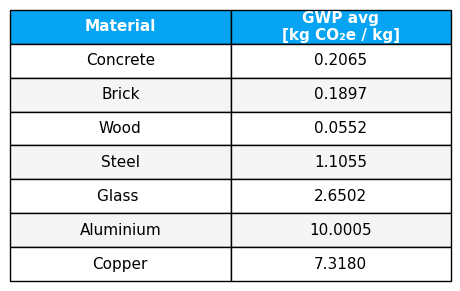

In [6]:
# ── Table: Carbon intensity per material ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
ax.axis('off')

table_data = [[mat, f"{val:.4f}"] for mat, val in zip(CI["Material"], CI["GWP avg"])]
col_labels = ["Material", "GWP avg\n[kg CO₂e / kg]"]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 1.8)

# Style header row
for col in range(2):
    table[0, col].set_facecolor("#06A4F3")
    table[0, col].set_text_props(color='white', fontweight='bold')

# Alternating row colours
for row in range(1, len(table_data) + 1):
    color = '#F5F5F5' if row % 2 == 0 else 'white'
    for col in range(2):
        table[row, col].set_facecolor(color)

plt.tight_layout()
plt.show()

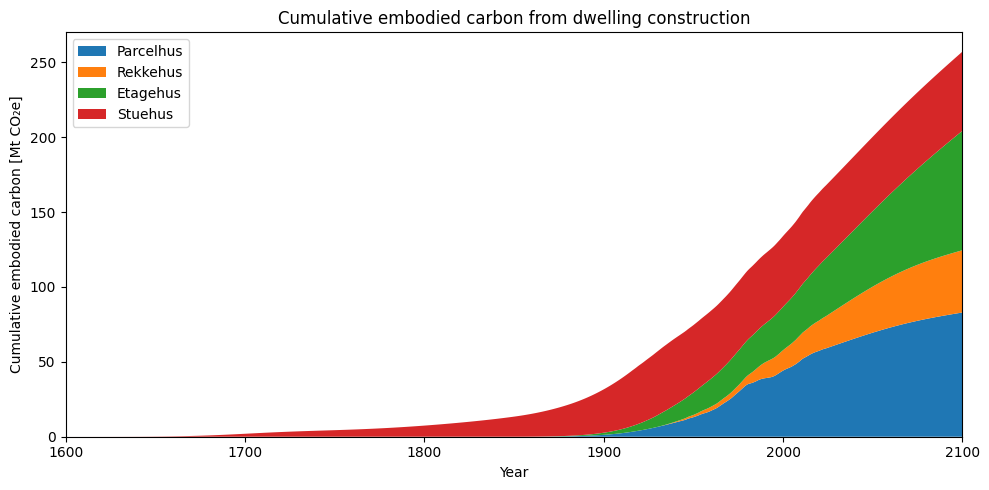

In [22]:
# ── Cumulative emissions over time ───────────────────────────────────────────
# Cumulative sum along the cohort (time) axis gives total emissions up to each year
emissions_by_type = Emissions_CJM.sum(axis=2)              # (501, 4): sum over materials
cumulative_by_type = np.cumsum(emissions_by_type, axis=0)  # (501, 4): running total

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(years, [cumulative_by_type[:, j] / 1e9 for j in range(len(types))],
             labels=types)
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative embodied carbon [Mt CO₂e]")
ax.set_title("Cumulative embodied carbon from dwelling construction")
ax.set_xlim(1600, 2100)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

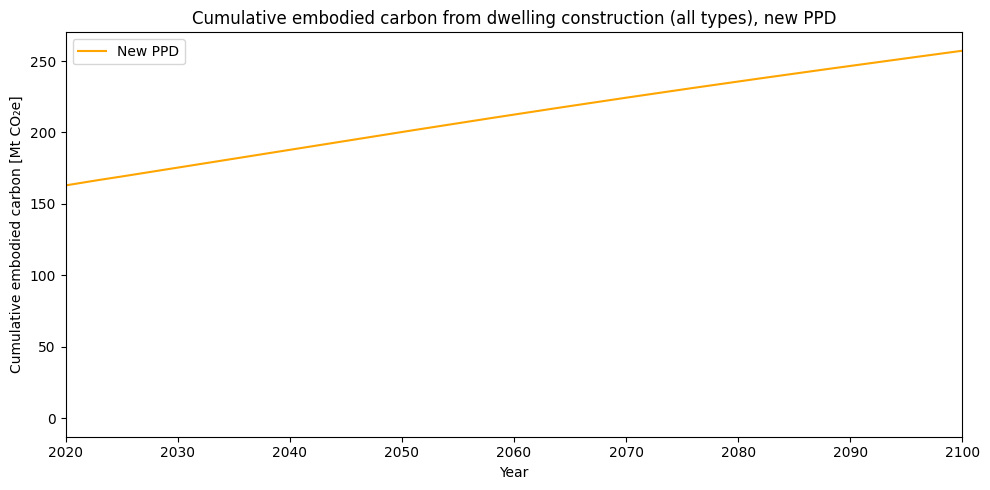

In [ ]:
# ── Cumulative emissions — total across all types ────────────────────────────
cumulative_total = cumulative_by_type.sum(axis=1)  # (501,): sum over types

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, cumulative_total / 1e9, label="New PPD", color="orange")
#ax.plot(years, cumulative_total_newFApD / 1e9, label="New FApD", color="purple")
#ax.plot(years, cumulative_total_newTS / 1e9, label="New type split", color="green")
'''if "cumulative_total_baseline" in dir():
    ax.plot(years, cumulative_total_baseline / 1e9, "--", label="Baseline", color="grey")
    pct = (cumulative_total[-1] - cumulative_total_baseline[-1]) / cumulative_total_baseline[-1] * 100
    ax.text(0.98, 0.05, f"{pct:+.1f}% by 2100", transform=ax.transAxes,
            ha="right", fontsize=16, color="steelblue")'''
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative embodied carbon [Mt CO₂e]")
ax.set_title("Cumulative embodied carbon from dwelling construction (all types), new PPD")
ax.set_xlim(2020, 2100)
ax.legend()
plt.tight_layout()
plt.show()

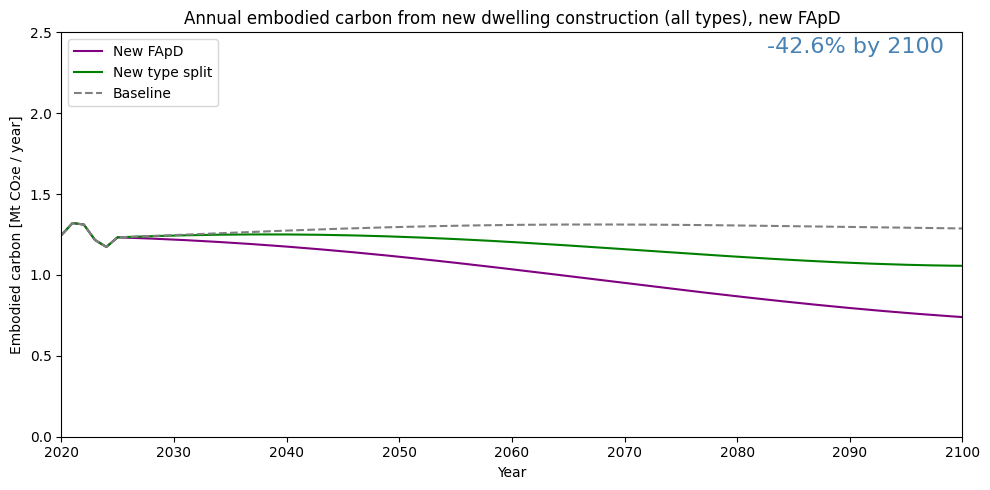

In [ ]:
# ── Annual embodied carbon — total across all types ──────────────────────────
# Each point = embodied carbon emitted that year from new construction
emissions_total = emissions_by_type.sum(axis=1)  # (501,): sum over types

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, emissions_total / 1e9, label="New PPD", color="orange")
#ax.plot(years, emissions_total_newFApD / 1e9, label="New FApD", color="purple")
#ax.plot(years, emissions_total_newTS / 1e9, label="New type split", color="green")
#if "emissions_total_baseline" in dir():
#    ax.plot(years, emissions_total_baseline / 1e9, "--", label="Baseline", color="grey")
 #   pct = (emissions_total[-1] - emissions_total_baseline[-1]) / emissions_total_baseline[-1] * 100
  #  ax.text(0.98, 0.95, f"{pct:+.1f}% by 2100", transform=ax.transAxes,
   #         ha="right", fontsize=16, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Embodied carbon [Mt CO₂e / year]")
ax.set_title("Annual embodied carbon from new dwelling construction (all types), new PPD")
ax.set_xlim(2020, 2100)
ax.set_ylim(0, 2.5)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Save baseline for scenario comparison ────────────────────────────────────
# Run with scenario cell commented OUT to capture baseline values.
# These are then available to plot alongside scenario results.
cumulative_total_baseline = cumulative_total.copy()  # (501,): cumulative all types
emissions_total_baseline  = emissions_total.copy()   # (501,): annual all types

#cumulative_total_newMI = cumulative_total.copy()  
#emissions_total_newMI  = emissions_total.copy()

#cumulative_total_newTS = cumulative_total.copy()  
#emissions_total_newTS  = emissions_total.copy()

#cumulative_total_newFApD = cumulative_total.copy()  
#emissions_total_newFApD  = emissions_total.copy()

NameError: name 'emissions_total' is not defined

In [ ]:
# ── Key results summary ───────────────────────────────────────────────────────
report_years = [1980, 2000, 2020, 2050, 2100]

# Pre-compute emissions_by_year and cumulative if not already in scope
emissions_by_year  = Emissions_CJM.sum(axis=(1, 2))          # (501,) kgCO2e/yr
emissions_by_type  = Emissions_CJM.sum(axis=2)               # (501, 4)
cumulative_by_type = np.cumsum(emissions_by_type, axis=0)    # (501, 4)
cumulative_total   = cumulative_by_type.sum(axis=1)          # (501,)

print("=" * 60)
print("STOCK_TCJME — KEY RESULTS")
print("=" * 60)

# 1. Annual emissions in key years
print("\n── Annual embodied carbon emissions [Mt CO₂e/yr] ──")
header = f"{'Year':<8}" + "".join(f"{t[:8]:>12}" for t in types) + f"{'TOTAL':>12}"
print(header)
print("-" * len(header))
for yr in report_years:
    idx = np.argmin(np.abs(years - yr))
    row = f"{yr:<8}"
    for j in range(len(types)):
        row += f"{emissions_by_type[idx, j] / 1e9:>12.2f}"
    row += f"{emissions_by_year[idx] / 1e9:>12.2f}"
    print(row)


# 2. Cumulative emissions by key year
print("\n── Cumulative embodied carbon [Mt CO₂e] ──")
header2 = f"{'Year':<8}" + "".join(f"{t[:8]:>12}" for t in types) + f"{'TOTAL':>12}"
print(header2)
print("-" * len(header2))
for yr in report_years:
    idx = np.argmin(np.abs(years - yr))
    row = f"{yr:<8}"
    for j in range(len(types)):
        row += f"{cumulative_by_type[idx, j] / 1e9:>12.1f}"
    row += f"{cumulative_total[idx] / 1e9:>12.1f}"
    print(row)

# 3. Total emissions by material (all cohorts 1600–2100)
print("\n── Total emissions by material [Mt CO₂e] (1600–2100) ──")
total_all = Emissions_CJM.sum()
for m, mat in enumerate(materials):
    val = Emissions_CJM[:, :, m].sum()
    print(f"  {mat:<12}: {val/1e9:>7.1f}  ({val/total_all*100:.1f}%)")
print(f"  {'TOTAL':<12}: {total_all/1e9:>7.1f}")

# 4. Peak emission year
peak_idx = np.argmax(emissions_by_year)
print(f"\n── Peak annual emissions ──")
print(f"  Year : {years[peak_idx]}")
print(f"  Value: {emissions_by_year[peak_idx]/1e9:.2f} Mt CO₂e")

print("\n" + "=" * 60)

STOCK_TCJME — KEY RESULTS

── Annual embodied carbon emissions [Mt CO₂e/yr] ──
Year        Parcelhu    Rekkehus    Etagehus     Stuehus       TOTAL
--------------------------------------------------------------------
1980            0.84        0.32        0.18        0.05        1.39
2000            0.71        0.32        0.33        0.06        1.41
2020            0.41        0.29        0.53        0.02        1.25
2050            0.37        0.32        0.49        0.04        1.24
2100            0.20        0.15        0.64        0.08        1.06

── Cumulative embodied carbon [Mt CO₂e] ──
Year        Parcelhu    Rekkehus    Etagehus     Stuehus       TOTAL
--------------------------------------------------------------------
1980            34.9         5.7        23.8        46.3       110.7
2000            44.2        13.6        29.0        47.3       134.1
2020            57.4        20.2        36.9        48.6       163.0
2050            69.5        30.7        50.5     